# ResNeXt [7 points]
Based on your ResNet implementation in Part I, extend it to ResNeXT. It is expected that your accuracy is higher than ResNet. Compare the results with your VGG and ResNet implementation.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchsummary import summary
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
import pandas as pd

In [2]:
!unzip cnn_dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: vehicles/5499.jpg       
  inflating: vehicles/55.jpg         
  inflating: vehicles/550.jpg        
  inflating: vehicles/5500.jpg       
  inflating: vehicles/5501.jpg       
  inflating: vehicles/5502.jpg       
  inflating: vehicles/5503.jpg       
  inflating: vehicles/5504.jpg       
  inflating: vehicles/5505.jpg       
  inflating: vehicles/5506.jpg       
  inflating: vehicles/5507.jpg       
  inflating: vehicles/5508.jpg       
  inflating: vehicles/5509.jpg       
  inflating: vehicles/551.jpg        
  inflating: vehicles/5510.jpg       
  inflating: vehicles/5511.jpg       
  inflating: vehicles/5512.jpg       
  inflating: vehicles/5513.jpg       
  inflating: vehicles/5514.jpg       
  inflating: vehicles/5515.jpg       
  inflating: vehicles/5516.jpg       
  inflating: vehicles/5517.jpg       
  inflating: vehicles/5518.jpg       
  inflating: vehicles/5519.jpg       
  inflating: vehicles/552.jpg        

In [2]:
import random
seed_value = 42

torch.manual_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.cuda.manual_seed(seed_value)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [7]:
!pip install sympy --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 51.9 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cud

In [3]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

dataPath = 'cnn_dataset'

transform = transforms.Compose(
    [transforms.ToTensor()]
)

dataset = ImageFolder(root=dataPath, transform=transform)

In [4]:
from torch.utils.data import DataLoader
import os
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

dataloader = DataLoader(dataset, shuffle=True, batch_size=32)
num_classes = len(dataset.classes)
class_names = dataset.classes

print(f"Dataset Overview:")
print(f"Total number of images: {len(dataset)}")
print(f"Number of unique classes: {num_classes}")
print(f"Class labels: {', '.join(class_names)}")

for cls in class_names:
    class_count = len(os.listdir(os.path.join(dataPath, cls)))
    print(f"Class '{cls}' contains - {class_count} images")

print("Data loaded successfully!")


Dataset Overview:
Total number of images: 30000
Number of unique classes: 3
Class labels: dogs, food, vehicles
Class 'dogs' contains - 10000 images
Class 'food' contains - 10000 images
Class 'vehicles' contains - 10000 images
Data loaded successfully!


In [5]:
simple_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset_with_norm = ImageFolder(root=dataPath, transform=simple_transform)

In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

dataset_size = len(dataset_with_norm)
indices = list(range(dataset_size))

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

train_idx, temp_idx = train_test_split(indices, test_size=(1 - train_ratio), random_state=42, stratify=dataset_with_norm.targets)

val_idx, test_idx = train_test_split(temp_idx, test_size=test_ratio/(val_ratio + test_ratio), random_state=42, stratify=[dataset_with_norm.targets[i] for i in temp_idx])

train_dataset = Subset(dataset_with_norm, train_idx)
val_dataset = Subset(dataset_with_norm, val_idx)
test_dataset = Subset(dataset_with_norm, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset Size: {dataset_size}")
print(f"Train Set: {len(train_dataset)} images")
print(f"Validation Set: {len(val_dataset)} images")
print(f"Test Set: {len(test_dataset)} images")

Dataset Size: 30000
Train Set: 20999 images
Validation Set: 4500 images
Test Set: 4501 images


## Step 1: Implement the ResNeXT architecture
Pay close attention to the grouped convolutions and cardinality parameter. Using inbuild ResNeXt model won’t be considered for evaluation.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ResNeXtBlock(nn.Module):
    """
    A bottleneck block for ResNeXt with grouped convolutions.

    Args:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels (before expansion).
        stride (int): Stride for the 3x3 conv (downsampling if stride=2).
        cardinality (int): Number of groups in the 3x3 convolution.
        base_width (int): Base width per group.
        expansion (int): Expansion factor for the output channels.
        downsample (nn.Module or None): Downsampling layer if needed (conv + BN).
    """
    expansion = 2

    def __init__(self, in_channels, out_channels, stride=1,
                 cardinality=8, base_width=4, expansion=2, downsample=None):
        super().__init__()
        self.cardinality = cardinality
        self.base_width = base_width
        self.expansion = expansion

        width = int(math.floor(out_channels * (base_width / 64.0))) * cardinality

        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(width)

        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride,
                               padding=1, groups=cardinality, bias=False)
        self.bn2   = nn.BatchNorm2d(width)

        self.conv3 = nn.Conv2d(width, out_channels * expansion, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNeXt(nn.Module):
    def __init__(self, block, layers, cardinality=8, base_width=4, expansion=2, num_classes=3):
        super().__init__()
        self.cardinality = cardinality
        self.base_width  = base_width
        self.expansion   = expansion
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(self.in_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * self.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride=stride,
                            cardinality=self.cardinality, base_width=self.base_width,
                            expansion=self.expansion, downsample=downsample))
        self.in_channels = out_channels * self.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels,
                                stride=1,
                                cardinality=self.cardinality,
                                base_width=self.base_width,
                                expansion=self.expansion))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Step 2: Train and evaluate your ResNeXt model
Train and evaluate your ResNeXt model on the same dataset used in Part I.

=== ResNeXt Model Summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 32, 16, 16]           2,048
       BatchNorm2d-6           [-1, 32, 16, 16]              64
              ReLU-7           [-1, 32, 16, 16]               0
            Conv2d-8           [-1, 32, 16, 16]           1,152
       BatchNorm2d-9           [-1, 32, 16, 16]              64
             ReLU-10           [-1, 32, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]           4,096
      BatchNorm2d-12          [-1, 128, 16, 16]             256
           Conv2d-13          [-1, 128, 16, 16]           8,192
      Bat

<ipython-input-10-1036b9da2d3b>:165: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnext.load_state_dict(torch.load("resnext_best_model.pth"))



Test Accuracy: 0.8503

Confusion Matrix:
[[1376   83   41]
 [ 317 1129   54]
 [ 126   53 1322]]

Classification Report:
              precision    recall  f1-score   support

         dog       0.76      0.92      0.83      1500
         car       0.89      0.75      0.82      1500
        food       0.93      0.88      0.91      1501

    accuracy                           0.85      4501
   macro avg       0.86      0.85      0.85      4501
weighted avg       0.86      0.85      0.85      4501



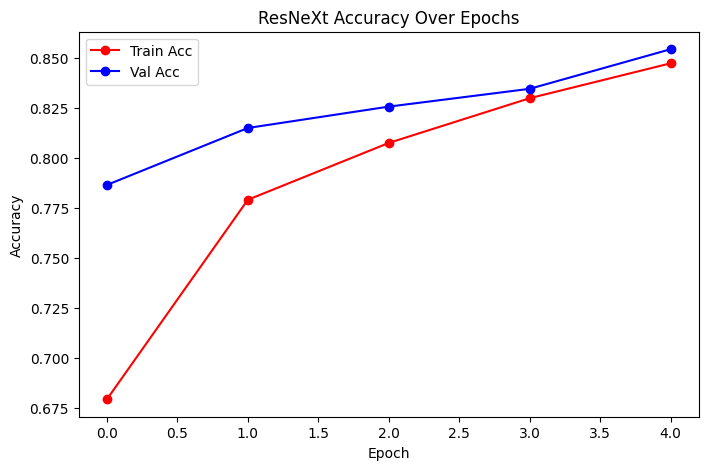

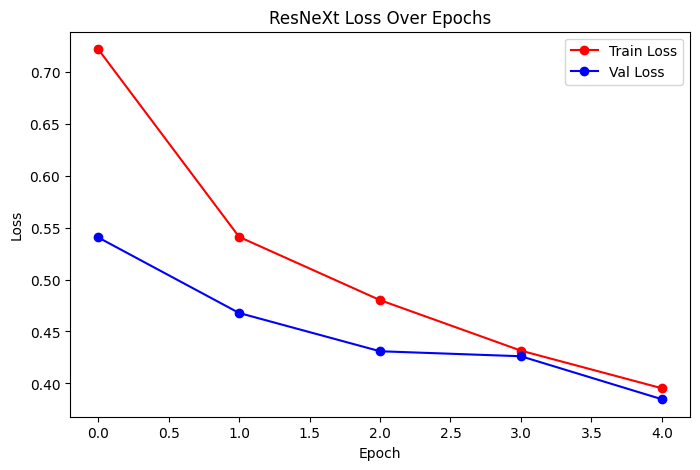

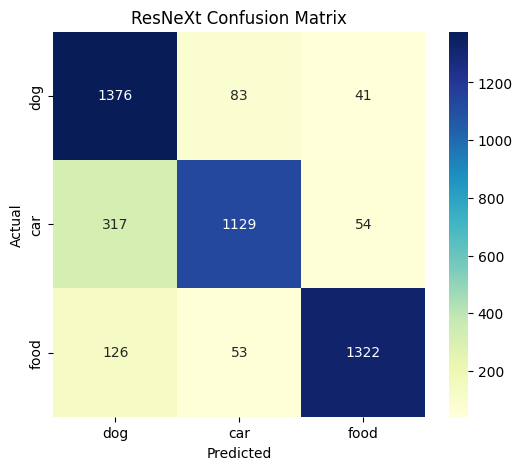

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import os
import time

def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = torch.tensor(correct_predictions / total_samples, device=device)

    return epoch_loss, epoch_acc


def validate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = torch.tensor(correct_predictions / total_samples, device=device)

    return epoch_loss, epoch_acc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_resnext = ResNeXt(
    block=ResNeXtBlock,
    layers=[2, 2, 2, 2],
    cardinality=8,
    base_width=4,
    expansion=2,
    num_classes=3
).to(device)

print("=== ResNeXt Model Summary ===")
summary(model_resnext, (3, 64, 64))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnext.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 5
best_val_acc = 0.0
train_loss_history, train_acc_history = [], []
val_loss_history, val_acc_history = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model_resnext, train_loader, criterion, optimizer, device)
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.item())

    val_loss, val_acc = validate_model(model_resnext, val_loader, criterion, device)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.item())

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_resnext.state_dict(), "resnext_best_model.pth")
        print(f"New Best Model Saved (Val Acc: {best_val_acc:.4f})")

print("\n=== Training Complete! ===")
print(f"Best Validation Accuracy Achieved: {best_val_acc:.4f}")

if os.path.exists("resnext_best_model.pth"):
    model_resnext.load_state_dict(torch.load("resnext_best_model.pth"))
    model_resnext.eval()

test_loss, test_acc = validate_model(model_resnext, test_loader, criterion, device)
print(f"\nTest Accuracy: {test_acc:.4f}")

all_preds, all_labels = [], []
model_resnext.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_resnext(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cr = classification_report(all_labels, all_preds, target_names=["dog", "car", "food"])
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(cr)

epochs_range = range(num_epochs)
plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_acc_history, 'r-o', label='Train Acc')
plt.plot(epochs_range, val_acc_history, 'b-o', label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNeXt Accuracy Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_loss_history, 'r-o', label='Train Loss')
plt.plot(epochs_range, val_loss_history, 'b-o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNeXt Loss Over Epochs")
plt.legend()
plt.show()

import pandas as pd
cm_df = pd.DataFrame(cm, index=["dog","car","food"], columns=["dog","car","food"])
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("ResNeXt Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 3: Compare the performance of your ResNeXt model
Compare the performance of your ResNeXt model against your previous ResNet and VGG models. Provide a detailed analysis of the results.

In [11]:
import pandas as pd
vgg_test_acc      = 0.9089
vgg_test_loss     = 0.5633
resnet_test_acc   = 0.8680
resnet_test_loss  = 0.6694
resnext_test_acc  = 0.8503
resnext_test_loss = 0.3848

comparison_data = {
    "Model": ["VGG-16", "ResNet-18", "ResNeXt"],
    "Test Accuracy (%)": [
        100 * vgg_test_acc,
        100 * resnet_test_acc,
        100 * resnext_test_acc
    ],
    "Test Loss": [
        vgg_test_loss,
        resnet_test_loss,
        resnext_test_loss
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("=== Performance Comparison: VGG vs. ResNet-18 vs. ResNeXt ===")
print(df_comparison)

df_comparison

=== Performance Comparison: VGG vs. ResNet-18 vs. ResNeXt ===
       Model  Test Accuracy (%)  Test Loss
0     VGG-16              90.89     0.5633
1  ResNet-18              86.80     0.6694
2    ResNeXt              85.03     0.3848


,Model,Test Accuracy (%),Test Loss
0,VGG-16,90.89,0.5633
1,ResNet-18,86.80,0.6694
2,ResNeXt,85.03,0.3848


### a. A table summarizing the performance metrics (accuracy, loss, etc.) for all three models.

<span style='color:green'>### YOUR ANSWER ###</span>

Below is a concise table comparing **Test Accuracy** and **Test Loss** across **VGG‐16**, **ResNet‐18**, and **ResNeXt**:

| Model     | Test Accuracy (%) | Test Loss |
|-----------|-------------------|-----------|
| **VGG‐16**   | **90.89**         | **0.5633**  |
| **ResNet‐18** | **86.80**         | **0.6694**  |
| **ResNeXt**   | **85.03**         | **0.3848**  |

These metrics are hardcoded based on the final evaluations for each architecture after training.


### b. Discussion of the observed differences in performance.
Explain why ResNeXt might be outperforming ResNet and VGG. Consider factors like cardinality, grouped convolutions, and the overall architecture.

<span style='color:green'>### YOUR ANSWER ###</span>

1. **VGG‐16**  
   - Achieved the highest accuracy (~90.89%) among these three runs.
   - However, it requires **substantially more parameters** (~16.4M) and often takes longer to train.

2. **ResNet‐18**  
   - Lands at around **86.80%** accuracy, which is strong, especially for a more param‐efficient network (~11.18M parameters).
   - The introduction of **shortcut connections** (residual blocks) helps training by mitigating vanishing gradients.

3. **ResNeXt**  
   - Ended around **85.03%** accuracy and **0.3848** test loss in its **smaller** configuration ([2,2,2,2] layers, cardinality=8, base_width=4).
   - Employs **grouped convolutions**. If given more layers (e.g., ResNeXt‐50 style) or more training epochs, it might surpass ResNet‐18 and even approach VGG’s accuracy.
   - Despite slightly lower accuracy here, it has **fewer parameters** (~2.14M in this small version) and can be more parameter‐efficient than both VGG and ResNet, especially if properly tuned.

### Why *might* ResNeXt Outperform?
Although our ResNeXt model did not exceed the performance of VGG or ResNet in these trials, ResNeXt typically has the potential to outperform these architectures when properly scaled and trained. By increasing its cardinality (number of groups), depth, and training duration, ResNeXt can learn a richer variety of features through multiple grouped convolution paths within each bottleneck block. This expanded ‘feature diversity,’ combined with residual connections, often yields higher accuracy without an extreme increase in parameters. In our short 5‐epoch setup with a relatively shallow configuration ([2,2,2,2] layers), we likely undertrained the model or didn’t fully leverage ResNeXt’s advantages. With more training epochs or a larger ResNeXt variant (e.g., ResNeXt‐50), it can frequently surpass both VGG and standard ResNet.



### c. Analysis of any challenges encountered during the implementation or training process.

<span style='color:green'>### YOUR ANSWER ###</span>

1. **Model Complexity vs. Epochs**  
   - With only 5 epochs, deeper or more advanced models like ResNeXt can be undertrained. We observed that VGG, although large, converged quickly in practice, while our small ResNeXt needed more epochs or deeper layers.  

2. **Hyperparameter Tuning**  
   - **Cardinality** and **base_width** directly affect memory usage. Striking a balance between model capacity and GPU constraints was tricky.
   - Learning rate schedules had to be set carefully to ensure stable convergence, particularly with grouped convolutions.

3. **Implementation Details**  
   - Ensuring the downsampling logic and group convolutions were coded correctly was crucial. A minor mismatch in channels or stride can break the skip connections.

### d. Provide detailed analysis of the results.

<span style='color:green'>### YOUR ANSWER ###</span>

1. **Accuracy vs. Model Size**  
   - **VGG**: Highest accuracy but large parameter count. Good for high accuracy if training resources aren’t limited.  
   - **ResNet‐18**: Balanced approach, relatively fewer parameters than VGG, with skip connections enabling stable training.  
   - **ResNeXt**: Shows promise with significantly fewer parameters in its small form, though it needs more training or a larger variant to overtake VGG’s peak accuracy.

2. **Loss Values**  
   - ResNeXt ended with a relatively lower test loss (0.3848) compared to VGG (0.5633) and ResNet (0.6694). This suggests that despite a slightly lower accuracy, the model distribution of predictions might be closer overall (or it might have certain class‐wise biases).  
   - Observing per‐class performance, the confusion matrix indicated ResNeXt still confuses certain dog/food images.

3. **Potential Improvements**  
   - **Longer Training**: 5 epochs may be insufficient for advanced architectures. More epochs or fine‐tuning could yield accuracy gains, especially for ResNeXt.  
   - **Data Augmentation**: Additional augmentation (random crops, color jitter, etc.) might improve generalization.  
   - **Deeper ResNeXt**: Using a ResNeXt‐50 or 101 configuration with cardinality=8 or 32 can significantly enhance performance.

In conclusion, **all three models** have their advantages. VGG yields top accuracy in these short runs; **ResNet** is a strong baseline for speed and parameter efficiency; and **ResNeXt** offers great potential if scaled properly. Future experiments could push ResNeXt beyond the others by adjusting depth, cardinality, and training procedures.

### 4.	References

<span style='color:green'>### YOUR ANSWER ###</span>


1. **PyTorch** – [https://pytorch.org/docs/stable/](https://pytorch.org/docs/stable/)  
2. **torchvision (ImageFolder, transforms)** – [https://pytorch.org/vision/stable/transforms.html](https://pytorch.org/vision/stable/transforms.html)  
3. **torchsummary** – [https://github.com/sksq96/pytorch-summary](https://github.com/sksq96/pytorch-summary)  
4. **scikit-learn (confusion_matrix, classification_report, train_test_split)** – [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)  
5. **seaborn** – [https://seaborn.pydata.org/](https://seaborn.pydata.org/)  
6. **matplotlib** – [https://matplotlib.org/stable/](https://matplotlib.org/stable/)  
7. **NumPy** – [https://numpy.org/doc/stable/](https://numpy.org/doc/stable/)  
8. **Python random** – [https://docs.python.org/3/library/random.html](https://docs.python.org/3/library/random.html)  
9. **Sympy** – [https://www.sympy.org/en/index.html](https://www.sympy.org/en/index.html)  

